# train an agent to play Ms. Pac-Man

**Choose three numbers. Run the notebook. Watch what the agent learns.**

The agent sees the game screen, chooses a move, and receives a reward from the game.
A neural network learns a value for each move through trial and error.

1. Open this notebook in Jupyter, VS Code, or Google Colab. In Colab, select **Runtime → Change runtime type → T4 GPU** if available.
2. Choose your three settings in the next cell.
3. Choose **Run All** (Colab: **Runtime → Run all**). Setup runs automatically. Local gameplay samples open above VS Code in a floating player at **4× speed**; a copy also appears inline.
4. Compare the five before/after scores and save your results.

If using Claude Code or Codex, ask it to run this notebook. The code tells it to ask you for your three choices before training.

A short run checks that everything works. Learning useful Atari behavior can take much longer; more episodes do not guarantee better play.

## 1. your three choices

| Setting | Meaning | Starting point |
|---|---|---|
| **Exploration** | Fraction of training moves chosen randomly. `0.20` means 20%. | `0.20` |
| **Episodes** | How many games to train on. Each game ends at game over or a fixed time limit. | `100` |
| **Learning rate** | How much the network changes at each update. | `0.0001` |

Change only the three numbers below. Try `5` episodes for a first check, then a longer run.
For this experiment, exploration stays **constant** so its meaning is easy to compare across runs.
The short replay warm-up uses random moves before learning starts.

In [1]:
# AI ASSISTANT INSTRUCTION:
# Before running training, ask the student:
# "Which exploration rate (0 to 1), number of episodes (positive whole number),
# and learning rate (greater than 0 and at most 1) do you want to use?"
# Explain the three choices briefly. Wait for their answer, then edit ONLY
# these three values. If they already chose values in this conversation,
# use those choices without asking again. Do not silently choose for them.
# The remaining cells are ready to run without student edits.

EXPLORATION = 0.20
EPISODES = 500
LEARNING_RATE = 0.0001

### check the choices

These checks catch typos before a long experiment starts. They do not change your settings.

In [2]:
import math
assert (
    isinstance(EXPLORATION, (int, float))
    and not isinstance(EXPLORATION, bool)
    and math.isfinite(EXPLORATION) and 0 <= EXPLORATION <= 1
), "Exploration must be between 0 and 1."
assert (
    isinstance(EPISODES, int) and not isinstance(EPISODES, bool) and EPISODES > 0
), "Episodes must be a positive whole number."
assert (
    isinstance(LEARNING_RATE, (int, float))
    and not isinstance(LEARNING_RATE, bool)
    and math.isfinite(LEARNING_RATE) and 0 < LEARNING_RATE <= 1
), "Learning rate must be greater than 0 and at most 1."
print(f"Your experiment: {EXPLORATION:.0%} exploration, {EPISODES} episodes, learning rate {LEARNING_RATE:g}.")

Your experiment: 20% exploration, 500 episodes, learning rate 0.0001.


## 2. automatic setup

Run this once per fresh session. It installs missing packages into the notebook's Python environment.
Python 3.11–3.13 is recommended. No separate game download is needed. For local popup playback, keep `pacman_player.py` next to this notebook and use a Python kernel with Tk (the local `py313` kernel supports it). Colab and machines without a desktop keep the fast inline preview.
If a package was already imported before an upgrade, restart the kernel and choose Run All again.

In [3]:
%pip -q install "torch>=2.6,<3" "gymnasium==1.3.0" "ale-py==0.11.2" "opencv-python-headless==4.14.0.94" "numpy>=2,<3" "matplotlib>=3.9,<4" "Pillow>=10,<13"

Note: you may need to restart the kernel to use updated packages.


### load the tools

Gymnasium runs the game, PyTorch learns from its screens, and Pillow saves gameplay. This cell also prints the actual Python and package versions, so runs can be compared.

In [4]:
import csv
import json
import platform
import random
import shutil
import time
from collections import deque
from datetime import datetime
from pathlib import Path
from importlib.metadata import version

import ale_py
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from PIL import Image as PILImage
from IPython.display import Image, FileLink, display

gym.register_envs(ale_py)
# Keep CPU thread overhead manageable on laptops.
torch.set_num_threads(min(4, torch.get_num_threads()))


VERSIONS = {p: version(p) for p in ['torch', 'gymnasium', 'ale-py', 'opencv-python-headless', 'numpy', 'matplotlib', 'Pillow']}
print(f"Python {platform.python_version()} | {platform.platform()}")
print(VERSIONS)

Python 3.12.14 | macOS-26.5.1-arm64-arm-64bit
{'torch': '2.14.0', 'gymnasium': '1.3.0', 'ale-py': '0.11.2', 'opencv-python-headless': '4.14.0.94', 'numpy': '2.5.3', 'matplotlib': '3.11.2', 'Pillow': '12.3.0'}


### fixed experiment settings

These values keep experiments comparable. One **decision** advances four game frames. The agent remembers 5,000 past decisions and learns from 32 at a time. The first 1,000 decisions collect experience; after that, learning happens every four decisions. You only need to edit the three choices in section 1.

In [5]:
# Fixed classroom settings. Students only need the three choices above.
SEED = 42
MAX_STEPS = 3000          # Agent decisions per game, about 200 seconds of game time.
FRAME_SKIP = 4           # Four emulator frames per agent decision, applied once.
REPLAY_CAPACITY = 5000   # About 168 MiB of pixel data, allocated gradually.
BATCH_SIZE = 32
WARMUP_STEPS = 1000      # Random-action collection before any weight updates.
TRAIN_EVERY = 4          # One update every four training decisions.
TARGET_EVERY = 1000      # Copy learned weights to target every 1,000 decisions.
GAMMA = 0.99             # How much future rewards count.
DEMO_EVERY = 25          # Episodes between gameplay demonstrations.
EVAL_SEEDS = [101, 202, 303, 404, 505]
EVAL_EXPLORATION = 0.05  # Identical before/after; independent of training choice.


### faster sample playback

Samples play **4× faster**: 20 seconds of game time takes about five seconds to watch. We save every fourth preview frame and keep a normal display interval, avoiding tiny GIF delays that viewers often clamp. This only changes the recording and playback; every game decision still runs normally.

Local samples open automatically in an **always-on-top popup** with Pause, Replay, and a pin toggle. Each sample plays exactly twice and stops on its final frame. Replay starts two more plays. Closing the popup leaves training running. Set `SHOW_POPUPS = False` for inline playback only.

In [6]:
PREVIEW_SPEED = 4
PREVIEW_PLAYS = 2
SHOW_POPUPS = True
PREVIEW_SECONDS = 20
PREVIEW_STRIDE = PREVIEW_SPEED
PREVIEW_DECISIONS = round(PREVIEW_SECONDS * 60 / FRAME_SKIP)
PREVIEW_FRAME_MS = round(1000 * FRAME_SKIP / 60)

## 3. the game and the learning rule

The network sees **four grayscale 84 × 84 screens** so it can infer movement.
Its outputs are estimated future rewards for the available moves, not probabilities.

The agent keeps past experiences in a small replay memory. It samples them to update the network.
A second, slower-changing network supplies the learning target:

**target = reward + discounted value of the next screen**

At game over, there is no future reward. At a time limit, the game could have continued, so we keep the future-value term.
Learning uses rewards clipped to −1 through +1; every score you see is the **original game score**.
The implementation below is ready to use. You do not need to edit it.

### 3a. turn game screens into observations

Start Ms. Pac-Man, reduce each screen to 84 × 84 grayscale pixels, and stack four screens. A single image shows position; a short sequence also reveals movement. Reset starts with four copies of the new game screen.

In [7]:
def make_env():
    env = gym.make("ALE/MsPacman-v5", frameskip=1,
                   repeat_action_probability=0.25, render_mode="rgb_array")
    env = gym.wrappers.AtariPreprocessing(
        env, noop_max=30, frame_skip=FRAME_SKIP, screen_size=84,
        terminal_on_life_loss=False, grayscale_obs=True, scale_obs=False)
    env = gym.wrappers.FrameStackObservation(env, stack_size=4, padding_type="reset")
    return gym.wrappers.TimeLimit(env, max_episode_steps=MAX_STEPS)

### 3b. estimate the value of each move

The convolution layers look for patterns in the screens. The final layer produces one number per move: its estimated future reward. `forward` scales pixel values from 0–255 to 0–1 before using them.

In [8]:
class DQN(nn.Module):
    def __init__(self, n_actions):
        super().__init__()
        # Read visual patterns, then produce one value per available move.
        self.layers = nn.Sequential(
            nn.Conv2d(4, 32, 8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2), nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1), nn.ReLU(),
            nn.Flatten(), nn.Linear(3136, 512), nn.ReLU(),
            nn.Linear(512, n_actions))

    def forward(self, screens):
        return self.layers(screens.float() / 255.0)

### 3c. remember past experience

Each memory stores the screen stack, move, reward, next screen, and whether the game ended. Random batches mix experiences from different moments. Consecutive stacks share three frames, so we only store the one new frame to save memory.

In [9]:
class ReplayMemory:
    def __init__(self, capacity):
        self.items = deque(maxlen=capacity)

    def add(self, obs, action, reward, next_obs, terminated, truncated):
        # The next stack is [obs[1], obs[2], obs[3], new_frame].
        # Store five frames instead of two overlapping four-frame stacks.
        self.items.append((np.array(obs, dtype=np.uint8, copy=True), action,
                           float(np.clip(reward, -1, 1)),
                           np.array(next_obs[-1], dtype=np.uint8, copy=True),
                           bool(terminated), bool(truncated)))

    def sample(self, size, rng):
        batch = rng.sample(list(self.items), size)
        obs, actions, rewards, last_frames, ended, truncated = zip(*batch)
        obs = np.stack(obs)
        next_obs = np.concatenate([obs[:, 1:], np.stack(last_frames)[:, None]], axis=1)
        return obs, np.array(actions), np.array(rewards, dtype=np.float32), next_obs, np.array(ended), np.array(truncated)

    def __len__(self):
        return len(self.items)

### 3d. choose a move

With probability `epsilon`, try a random move (**explore**). Otherwise choose the move with the highest predicted value (**exploit**). Choosing a move does not update the network.

In [10]:
@torch.no_grad()
def choose_action(model, obs, epsilon, rng, n_actions):
    if rng.random() < epsilon:
        return rng.randrange(n_actions)
    device = next(model.parameters()).device
    screens = torch.as_tensor(np.asarray(obs), device=device).unsqueeze(0)
    return int(model(screens).argmax(dim=1).item())

### 3e. learn from a batch

1. Predict the value of each remembered move.
2. Build a target from its reward plus the next screen’s estimated value.
3. Measure the prediction error and adjust the network.

The target network changes less often to give learning a steadier reference. True game over removes future reward; reaching the time limit does not.

In [11]:
def learn(model, target, optimizer, batch):
    device = next(model.parameters()).device
    obs, actions, rewards, next_obs, ended, truncated = [torch.as_tensor(x, device=device) for x in batch]
    # 1. What value did the network predict for the move we took?
    values = model(obs).gather(1, actions.long().unsqueeze(1)).squeeze(1)
    # 2. What target does the observed reward suggest?
    with torch.no_grad():
        # Mask true termination only. A time limit still allows bootstrapping.
        targets = rewards + GAMMA * (~ended).float() * target(next_obs).max(dim=1).values
    # 3. Reduce the gap between prediction and target.
    loss = nn.functional.smooth_l1_loss(values, targets)
    if not torch.isfinite(loss):
        raise RuntimeError("Loss became non-finite. Start a new run with a smaller learning rate.")
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 10.0, error_if_nonfinite=True)
    optimizer.step()
    return float(loss.item())

### 3f. select working hardware

Try CUDA, Apple MPS, then CPU. A real batch tests prediction, backward pass, and a weight update before we commit to that device.

In [12]:
def select_device(n_actions):
    candidates = []
    if torch.cuda.is_available():
        candidates.append("cuda")
    if torch.backends.mps.is_available():
        candidates.append("mps")
    candidates.append("cpu")
    for candidate in candidates:
        try:
            # Test the actual network, minibatch, backward pass, and optimizer.
            probe = DQN(n_actions).to(candidate)
            optimizer = torch.optim.Adam(probe.parameters(), lr=LEARNING_RATE)
            screens = np.zeros((BATCH_SIZE, 4, 84, 84), dtype=np.uint8)
            batch = (screens, np.zeros(BATCH_SIZE, dtype=np.int64),
                     np.ones(BATCH_SIZE, dtype=np.float32), screens,
                     np.zeros(BATCH_SIZE, dtype=bool), np.zeros(BATCH_SIZE, dtype=bool))
            learn(probe, probe, optimizer, batch)
            print(f"Using {candidate.upper()}; training-batch check passed.")
            return torch.device(candidate)
        except RuntimeError as error:
            if candidate == "cpu":
                raise
            print(f"{candidate.upper()} check failed ({error}). Trying the next device.")

### check the first screen

Create the game, check the four-screen stack, and show the available joystick moves. If this cell succeeds, the game and learning hardware are ready.

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


Using MPS; training-batch check passed.
Available moves: ['NOOP', 'UP', 'RIGHT', 'LEFT', 'DOWN', 'UPRIGHT', 'UPLEFT', 'DOWNRIGHT', 'DOWNLEFT']


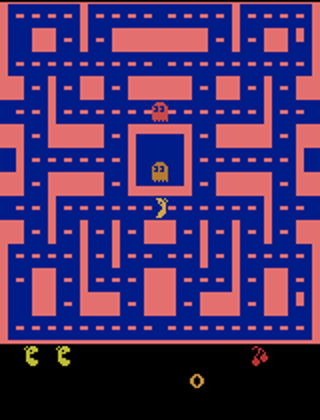

Replay pixel budget: 168 MiB, plus model and batch memory.


In [13]:
probe_env = make_env()
try:
    probe_obs, _ = probe_env.reset(seed=SEED)
    assert probe_obs.shape == (4, 84, 84) and probe_obs.dtype == np.uint8
    assert all(np.array_equal(probe_obs[0], frame) for frame in probe_obs)
    N_ACTIONS = int(probe_env.action_space.n)
    DEVICE = select_device(N_ACTIONS)
    print("Available moves:", probe_env.unwrapped.get_action_meanings())
    display(PILImage.fromarray(probe_env.render()).resize((320, 420)))
finally:
    probe_env.close()
print(f"Replay pixel budget: {REPLAY_CAPACITY * 5 * 84 * 84 / 2**20:.0f} MiB, plus model and batch memory.")

## 4. gameplay, scores, and saved results

Evaluation uses a separate game environment and the same five seeds before and after training.
It uses 5% random moves in both cases. Evaluation never changes the network or training memory.
The baseline is an **untrained network**, not a random-action agent.

GIFs show the first 20 seconds at most, compressed to about five seconds at 4× speed; the reported score covers the entire evaluated game, up to the fixed time limit.

### 4a. score complete games and record a short sample

All evaluation games run at full computing speed, with no waiting for playback. We record a short excerpt, but add rewards for the **entire game**. For the final preview we keep the excerpt from the game with the highest full-game score.

In [14]:
def evaluate(model, seeds, gif_path=None, record_best=False):
    env = make_env()
    scores, lengths, capped = [], [], []
    best_score, chosen_frames = -float("inf"), []
    was_training = model.training
    model.eval()
    try:
        for index, seed in enumerate(seeds):
            rng = random.Random(seed + 10000)
            obs, _ = env.reset(seed=seed)
            total, frames = 0.0, []
            capture = gif_path is not None and (record_best or index == 0)
            for step in range(MAX_STEPS):
                if capture and step < PREVIEW_DECISIONS and step % PREVIEW_STRIDE == 0:
                    frames.append(PILImage.fromarray(env.render()).copy())
                action = choose_action(model, obs, EVAL_EXPLORATION, rng, N_ACTIONS)
                obs, reward, ended, truncated, _ = env.step(action)
                total += reward
                if ended or truncated:
                    break
            scores.append(float(total))
            lengths.append(step + 1)
            capped.append(bool(truncated))
            if capture and (not record_best or total > best_score):
                chosen_frames, best_score = frames, total
    finally:
        env.close()
        model.train(was_training)
    if gif_path is not None and chosen_frames:
        chosen_frames[0].save(gif_path, save_all=True, append_images=chosen_frames[1:],
                              duration=PREVIEW_FRAME_MS, loop=PREVIEW_PLAYS - 1)
    return {"seeds": list(seeds), "scores": scores, "mean": float(np.mean(scores)),
            "steps": lengths, "time_limited": capped}

### 4b. show the sample

Always keep a playable GIF in the notebook. Both the inline GIF and the popup play exactly twice. When a local desktop and Tk are available, the separate floating player does not block the next learning update.

In [15]:
def show_sample(gif_path, label):
    """Display a recorded excerpt inline and, locally, above the notebook."""
    print(f"{label} | {PREVIEW_SPEED}× playback | {PREVIEW_PLAYS} plays | first {PREVIEW_SECONDS}s of game time")
    display(Image(filename=str(gif_path)))
    if not SHOW_POPUPS:
        return
    try:
        from pacman_player import show_popup
        opened = show_popup(gif_path, f"{label} · {PREVIEW_SPEED}× speed")
        if not opened:
            print("Popup unavailable in this kernel; use the fast inline preview.")
    except (ImportError, OSError) as error:
        print(f"Using the inline preview. Local popup helper unavailable: {error}")

### 4c. save a model for playback

A checkpoint stores the learned weights and action count. Reloading it lets us check the saved agent. It does not contain everything needed to resume the exact training session.

In [16]:
def save_checkpoint(model, path, episode, steps):
    # Portable playback checkpoint. This is not an exact training-resume snapshot:
    # replay, optimizer, and emulator state are intentionally not persisted.
    payload = {"model": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
               "n_actions": N_ACTIONS, "episode": episode, "steps": steps,
               "exploration": EXPLORATION, "learning_rate": LEARNING_RATE}
    temporary = path.with_suffix(".tmp")
    torch.save(payload, temporary)
    temporary.replace(path)

### 4d. save one row per game

The CSV keeps each completed game’s raw score, decisions, exploration, loss, and elapsed time. A game with no learning updates has no meaningful loss yet.

In [17]:
def save_metrics(rows, path):
    fields = ["episode", "score", "steps", "total_steps", "exploration", "mean_loss", "elapsed_seconds", "terminated", "truncated"]
    with path.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fields)
        writer.writeheader()
        writer.writerows(rows)

### 4e. draw the learning dashboard

The three panels show scores, prediction error, and exploration. Look at game scores as well as loss: reducing prediction error does not guarantee better play.

In [18]:
def plot_training(rows, path):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    if rows:
        episodes = [r["episode"] for r in rows]
        scores = [r["score"] for r in rows]
        smooth = [np.mean(scores[max(0, i - 24):i + 1]) for i in range(len(scores))]
        axes[0].plot(episodes, scores, alpha=0.35, label="Each training game")
        axes[0].plot(episodes, smooth, label="Up to 25-game average")
        axes[0].legend(fontsize=8)
        axes[1].plot(episodes, [r["mean_loss"] for r in rows])
        axes[2].plot(episodes, [r["exploration"] for r in rows])
    for ax, title in zip(axes, ["Raw training score", "Mean update loss", "Training exploration"]):
        ax.set(title=title, xlabel="Completed episode")
        ax.grid(alpha=0.2)
    axes[2].set_ylim(0, 1.05)
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.close(fig)

## 5. train your agent

The setup cell below starts a **fresh experiment** each time, using your three choices.
It saves the untrained baseline, trains, and prints a line after each episode plus a progress update every 500 decisions.
Every 25 episodes it opens a fast gameplay sample and saves a checkpoint and plot.

To stop early, use the notebook's **Interrupt / Stop** button once. The current model and completed-episode results are saved.
Then run the remaining cells to evaluate and download them. A run ending before warm-up finishes has no learning updates yet.
Each run has its own folder so earlier experiments stay available.

### 5a. start a fresh experiment

Create the two networks, empty replay memory, random seeds, and a unique results folder. This cell resets training. To try again, rerun from here or choose Run All.

In [19]:
# Each execution starts fresh, including network weights and replay memory.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
train_rng = random.Random(SEED)
replay_rng = random.Random(SEED + 1)
RUN_DIR = Path("pacman_runs") / datetime.now().strftime("%Y%m%d_%H%M%S_%f")
RUN_DIR.mkdir(parents=True, exist_ok=False)
(RUN_DIR / "demos").mkdir()
model = DQN(N_ACTIONS).to(DEVICE)
target = DQN(N_ACTIONS).to(DEVICE)
target.load_state_dict(model.state_dict())
target.eval()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
replay = ReplayMemory(REPLAY_CAPACITY)
history, demo_history = [], []
total_steps, completed_episodes, updates = 0, 0, 0

_training_started = False

### 5b. record the settings and test saving

Save the hardware and settings alongside the initial weights. Reload those weights immediately to catch any checkpoint problem before training.

In [20]:
config = {"exploration": EXPLORATION, "episodes_requested": EPISODES, "learning_rate": LEARNING_RATE,
          "seed": SEED, "device": str(DEVICE), "python": platform.python_version(),
          "platform": platform.platform(), "packages": VERSIONS,
          "environment": "ALE/MsPacman-v5", "frame_skip": FRAME_SKIP,
          "sticky_action_probability": 0.25, "noop_max": 30, "grayscale_size": 84,
          "stack_size": 4, "terminal_on_life_loss": False, "max_decisions_per_game": MAX_STEPS,
          "replay_capacity": REPLAY_CAPACITY, "warmup_decisions": WARMUP_STEPS,
          "batch_size": BATCH_SIZE, "train_every_decisions": TRAIN_EVERY,
          "target_sync_decisions": TARGET_EVERY, "gamma": GAMMA,
          "training_reward_clipping": [-1, 1], "eval_exploration": EVAL_EXPLORATION,
          "eval_seeds": EVAL_SEEDS, "preview_seconds": PREVIEW_SECONDS,
          "preview_speed": PREVIEW_SPEED, "preview_plays": PREVIEW_PLAYS,
          "preview_stride": PREVIEW_STRIDE,
          "preview_frame_ms": PREVIEW_FRAME_MS}
(RUN_DIR / "config.json").write_text(json.dumps(config, indent=2))
save_checkpoint(model, RUN_DIR / "untrained.pt", 0, 0)
# Check saving and loading before starting the long run.
roundtrip = torch.load(RUN_DIR / "untrained.pt", map_location="cpu", weights_only=True)
assert all(torch.equal(v.cpu(), roundtrip["model"][k]) for k, v in model.state_dict().items())
del roundtrip

### 5c. measure the starting point

Play five games before learning. This gives a baseline for the final comparison. The popup shows a short, accelerated excerpt from the first game.

Evaluating the untrained network on five games. This can take a few minutes.


Before training: [350.0, 500.0, 320.0, 800.0, 490.0] | mean: 492.0
Before training | 4× playback | 2 plays | first 20s of game time


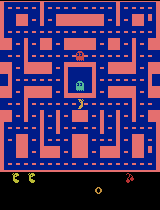

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'


In [21]:
print("Evaluating the untrained network on five games. This can take a few minutes.", flush=True)
baseline = evaluate(model, EVAL_SEEDS, RUN_DIR / "demos" / "episode_0000.gif")
(RUN_DIR / "baseline.json").write_text(json.dumps(baseline, indent=2))
print("Before training:", baseline["scores"], "| mean:", baseline["mean"])
show_sample(RUN_DIR / "demos" / "episode_0000.gif", "Before training")

### 5d. learn during one game

Repeat **choose → play → remember → learn** until game over or the time limit. The counters span all games, so warm-up happens once. Every 1,000 decisions, copy the learning network into the target network.

In [22]:
def train_one_episode(train_env, episode):
    """Collect experience and update the agent during one complete game."""
    global total_steps, updates
    obs, _ = train_env.reset(seed=SEED + episode)
    score, losses = 0.0, []
    for step in range(MAX_STEPS):
        epsilon = 1.0 if total_steps < WARMUP_STEPS else EXPLORATION
        action = choose_action(model, obs, epsilon, train_rng, N_ACTIONS)
        next_obs, reward, ended, truncated, _ = train_env.step(action)
        replay.add(obs, action, reward, next_obs, ended, truncated)
        obs = next_obs
        score += reward
        total_steps += 1
        if total_steps >= WARMUP_STEPS and len(replay) >= BATCH_SIZE and total_steps % TRAIN_EVERY == 0:
            losses.append(learn(model, target, optimizer, replay.sample(BATCH_SIZE, replay_rng)))
            updates += 1
        if total_steps % TARGET_EVERY == 0:
            target.load_state_dict(model.state_dict())
        if total_steps % 500 == 0:
            elapsed = time.monotonic() - started
            print(f"  Episode {episode}/{EPISODES} | {total_steps:,} decisions | {updates:,} updates | {elapsed / 60:.1f} min", flush=True)
        if ended or truncated:
            break
    return {"episode": episode, "score": float(score), "steps": step + 1,
            "total_steps": total_steps, "exploration": epsilon,
            "mean_loss": float(np.mean(losses)) if losses else float("nan"),
            "elapsed_seconds": time.monotonic() - started,
            "terminated": bool(ended), "truncated": bool(truncated)}

### 5e. save a progress sample

Every 25 completed games, evaluate on a separate game, show the fast popup, and save a checkpoint. Evaluation does not add experiences to replay or change weights.

In [23]:
def save_progress_sample(episode):
    gif_path = RUN_DIR / "demos" / f"episode_{episode:04d}.gif"
    demo = evaluate(model, EVAL_SEEDS[:1], gif_path)
    demo_history.append({"episode": episode, **demo})
    (RUN_DIR / "demo_scores.json").write_text(json.dumps(demo_history, indent=2))
    print("Separate demonstration score:", demo["scores"][0])
    save_checkpoint(model, RUN_DIR / f"episode_{episode:04d}.pt", episode, total_steps)
    plot_training(history, RUN_DIR / "training_dashboard.png")
    show_sample(gif_path, f"After {episode} training games")

### 5f. save the current result

Run this helper on completion, interruption, or failure. Checkpoints include all weight updates so far; the CSV contains completed games only.

In [24]:
def save_training_result(status):
    save_checkpoint(model, RUN_DIR / "trained.pt", completed_episodes, total_steps)
    save_metrics(history, RUN_DIR / "training.csv")
    plot_training(history, RUN_DIR / "training_dashboard.png")
    summary = {"status": status, "completed_episodes": completed_episodes,
               "total_decisions": total_steps, "learning_updates": updates,
               "elapsed_seconds_including_periodic_demos": time.monotonic() - started}
    (RUN_DIR / "training_summary.json").write_text(json.dumps(summary, indent=2))

### 5g. run the training games

This is the experiment loop. Each call plays one game and prints its score. **Interrupt / Stop** saves the current model; then continue to section 6. To start another experiment, rerun from 5a so the model, baseline, and results folder all reset together.

Episode 1/500 | score 130 | recent mean 130.0 | exploration 100%


  Episode 2/500 | 500 decisions | 0 updates | 0.0 min


  Episode 2/500 | 1,000 decisions | 1 updates | 0.0 min


Episode 2/500 | score 460 | recent mean 295.0 | exploration 20%


  Episode 3/500 | 1,500 decisions | 126 updates | 0.0 min


...

  Episode 24/500 | 15,500 decisions | 3,626 updates | 0.9 min


Episode 24/500 | score 1290 | recent mean 802.1 | exploration 20%


  Episode 25/500 | 16,000 decisions | 3,751 updates | 0.9 min


Episode 25/500 | score 310 | recent mean 782.4 | exploration 20%


Separate demonstration score: 390.0
After 25 training games | 4× playback | 2 plays | first 20s of game time


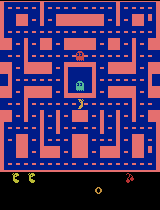

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'


  Episode 26/500 | 16,500 decisions | 3,876 updates | 1.0 min


Episode 26/500 | score 670 | recent mean 804.0 | exploration 20%


  Episode 27/500 | 17,000 decisions | 4,001 updates | 1.0 min


Episode 27/500 | score 570 | recent mean 808.4 | exploration 20%


...

  Episode 49/500 | 30,500 decisions | 7,376 updates | 1.8 min


Episode 49/500 | score 320 | recent mean 700.8 | exploration 20%


  Episode 50/500 | 31,000 decisions | 7,501 updates | 1.8 min


Episode 50/500 | score 470 | recent mean 707.2 | exploration 20%


Separate demonstration score: 270.0
After 50 training games | 4× playback | 2 plays | first 20s of game time


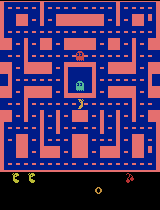

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'


  Episode 51/500 | 31,500 decisions | 7,626 updates | 1.8 min


Episode 51/500 | score 1000 | recent mean 720.4 | exploration 20%


  Episode 52/500 | 32,000 decisions | 7,751 updates | 1.9 min


  Episode 52/500 | 32,500 decisions | 7,876 updates | 1.9 min


...

  Episode 74/500 | 45,000 decisions | 11,001 updates | 2.8 min


Episode 74/500 | score 300 | recent mean 615.2 | exploration 20%


  Episode 75/500 | 45,500 decisions | 11,126 updates | 2.9 min


Episode 75/500 | score 400 | recent mean 612.4 | exploration 20%


Separate demonstration score: 200.0
After 75 training games | 4× playback | 2 plays | first 20s of game time


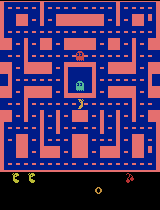

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'


  Episode 76/500 | 46,000 decisions | 11,251 updates | 2.9 min


  Episode 76/500 | 46,500 decisions | 11,376 updates | 2.9 min


Episode 76/500 | score 980 | recent mean 611.6 | exploration 20%


Episode 77/500 | score 370 | recent mean 605.2 | exploration 20%


...

Episode 99/500 | score 490 | recent mean 752.0 | exploration 20%


  Episode 100/500 | 60,500 decisions | 14,876 updates | 3.8 min


  Episode 100/500 | 61,000 decisions | 15,001 updates | 3.8 min


Episode 100/500 | score 560 | recent mean 758.4 | exploration 20%


Separate demonstration score: 280.0
After 100 training games | 4× playback | 2 plays | first 20s of game time


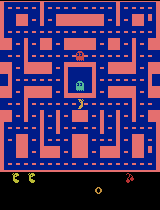

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'


  Episode 101/500 | 61,500 decisions | 15,126 updates | 3.8 min


Episode 101/500 | score 1270 | recent mean 770.0 | exploration 20%


  Episode 102/500 | 62,000 decisions | 15,251 updates | 3.9 min


Episode 102/500 | score 380 | recent mean 770.4 | exploration 20%


...

  Episode 124/500 | 75,000 decisions | 18,501 updates | 4.6 min


Episode 124/500 | score 1810 | recent mean 694.4 | exploration 20%


  Episode 125/500 | 75,500 decisions | 18,626 updates | 4.7 min


Episode 125/500 | score 490 | recent mean 691.6 | exploration 20%


Separate demonstration score: 500.0
After 125 training games | 4× playback | 2 plays | first 20s of game time


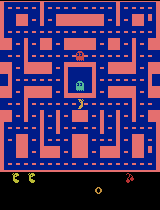

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'


  Episode 126/500 | 76,000 decisions | 18,751 updates | 4.8 min


Episode 126/500 | score 700 | recent mean 668.8 | exploration 20%


  Episode 127/500 | 76,500 decisions | 18,876 updates | 4.8 min


Episode 127/500 | score 730 | recent mean 682.8 | exploration 20%


...

Episode 149/500 | score 1810 | recent mean 906.0 | exploration 20%


  Episode 150/500 | 91,500 decisions | 22,626 updates | 5.9 min


  Episode 150/500 | 92,000 decisions | 22,751 updates | 6.0 min


Episode 150/500 | score 1060 | recent mean 928.8 | exploration 20%


Separate demonstration score: 980.0
After 150 training games | 4× playback | 2 plays | first 20s of game time


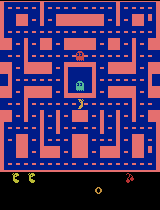

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'


  Episode 151/500 | 92,500 decisions | 22,876 updates | 6.1 min


Episode 151/500 | score 1460 | recent mean 959.2 | exploration 20%


  Episode 152/500 | 93,000 decisions | 23,001 updates | 6.1 min


Episode 152/500 | score 170 | recent mean 936.8 | exploration 20%


...

Episode 174/500 | score 710 | recent mean 782.8 | exploration 20%


  Episode 175/500 | 107,000 decisions | 26,501 updates | 7.2 min


  Episode 175/500 | 107,500 decisions | 26,626 updates | 7.2 min


Episode 175/500 | score 710 | recent mean 768.8 | exploration 20%


Separate demonstration score: 480.0
After 175 training games | 4× playback | 2 plays | first 20s of game time


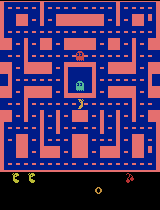

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'


Episode 176/500 | score 370 | recent mean 725.2 | exploration 20%


  Episode 177/500 | 108,000 decisions | 26,751 updates | 7.2 min


  Episode 177/500 | 108,500 decisions | 26,876 updates | 7.2 min


Episode 177/500 | score 570 | recent mean 741.2 | exploration 20%


...

Episode 199/500 | score 370 | recent mean 616.8 | exploration 20%


  Episode 200/500 | 120,500 decisions | 29,876 updates | 7.9 min


  Episode 200/500 | 121,000 decisions | 30,001 updates | 8.0 min


Episode 200/500 | score 600 | recent mean 612.4 | exploration 20%


Separate demonstration score: 210.0
After 200 training games | 4× playback | 2 plays | first 20s of game time


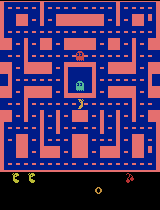

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'


  Episode 201/500 | 121,500 decisions | 30,126 updates | 8.0 min


Episode 201/500 | score 650 | recent mean 623.6 | exploration 20%


  Episode 202/500 | 122,000 decisions | 30,251 updates | 8.0 min


Episode 202/500 | score 1170 | recent mean 647.6 | exploration 20%


...

Episode 224/500 | score 670 | recent mean 863.2 | exploration 20%


  Episode 225/500 | 136,500 decisions | 33,876 updates | 8.9 min


  Episode 225/500 | 137,000 decisions | 34,001 updates | 8.9 min


Episode 225/500 | score 2090 | recent mean 922.8 | exploration 20%


Separate demonstration score: 200.0
After 225 training games | 4× playback | 2 plays | first 20s of game time


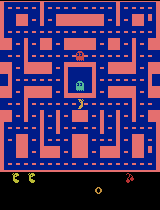

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'


  Episode 226/500 | 137,500 decisions | 34,126 updates | 9.0 min


Episode 226/500 | score 2360 | recent mean 991.2 | exploration 20%


  Episode 227/500 | 138,000 decisions | 34,251 updates | 9.0 min


Episode 227/500 | score 260 | recent mean 954.8 | exploration 20%


...

  Episode 249/500 | 151,500 decisions | 37,626 updates | 10.0 min


Episode 249/500 | score 500 | recent mean 898.8 | exploration 20%


  Episode 250/500 | 152,000 decisions | 37,751 updates | 10.0 min


Episode 250/500 | score 830 | recent mean 848.4 | exploration 20%


Separate demonstration score: 550.0
After 250 training games | 4× playback | 2 plays | first 20s of game time


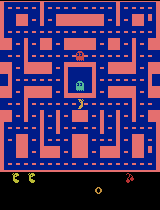

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'


  Episode 251/500 | 152,500 decisions | 37,876 updates | 10.1 min


  Episode 251/500 | 153,000 decisions | 38,001 updates | 10.1 min


Episode 251/500 | score 650 | recent mean 780.0 | exploration 20%


  Episode 252/500 | 153,500 decisions | 38,126 updates | 10.2 min


...

  Episode 274/500 | 167,000 decisions | 41,501 updates | 11.1 min


Episode 274/500 | score 1170 | recent mean 658.4 | exploration 20%


  Episode 275/500 | 167,500 decisions | 41,626 updates | 11.1 min


Episode 275/500 | score 510 | recent mean 645.6 | exploration 20%


Separate demonstration score: 380.0
After 275 training games | 4× playback | 2 plays | first 20s of game time


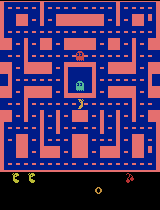

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'


  Episode 276/500 | 168,000 decisions | 41,751 updates | 11.2 min


Episode 276/500 | score 520 | recent mean 640.4 | exploration 20%


  Episode 277/500 | 168,500 decisions | 41,876 updates | 11.2 min


Episode 277/500 | score 730 | recent mean 652.0 | exploration 20%


...

  Episode 299/500 | 182,000 decisions | 45,251 updates | 12.0 min


Episode 299/500 | score 560 | recent mean 657.2 | exploration 20%


  Episode 300/500 | 182,500 decisions | 45,376 updates | 12.1 min


Episode 300/500 | score 440 | recent mean 654.4 | exploration 20%


Separate demonstration score: 250.0
After 300 training games | 4× playback | 2 plays | first 20s of game time


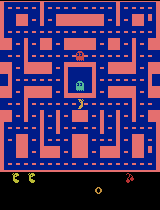

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'


  Episode 301/500 | 183,000 decisions | 45,501 updates | 12.1 min


Episode 301/500 | score 450 | recent mean 651.6 | exploration 20%


  Episode 302/500 | 183,500 decisions | 45,626 updates | 12.1 min


Episode 302/500 | score 400 | recent mean 638.4 | exploration 20%


...

  Episode 324/500 | 198,000 decisions | 49,251 updates | 13.1 min


Episode 324/500 | score 340 | recent mean 702.8 | exploration 20%


  Episode 325/500 | 198,500 decisions | 49,376 updates | 13.1 min


Episode 325/500 | score 490 | recent mean 704.8 | exploration 20%


Separate demonstration score: 3120.0
After 325 training games | 4× playback | 2 plays | first 20s of game time


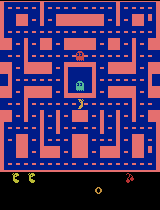

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'


  Episode 326/500 | 199,000 decisions | 49,501 updates | 13.2 min


  Episode 326/500 | 199,500 decisions | 49,626 updates | 13.2 min


Episode 326/500 | score 1080 | recent mean 730.0 | exploration 20%


Episode 327/500 | score 330 | recent mean 727.2 | exploration 20%


...

  Episode 349/500 | 213,000 decisions | 53,001 updates | 14.2 min


Episode 349/500 | score 370 | recent mean 623.6 | exploration 20%


  Episode 350/500 | 213,500 decisions | 53,126 updates | 14.2 min


Episode 350/500 | score 350 | recent mean 618.0 | exploration 20%


Separate demonstration score: 1210.0
After 350 training games | 4× playback | 2 plays | first 20s of game time


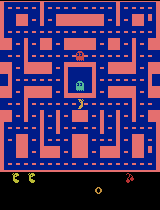

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'


  Episode 351/500 | 214,000 decisions | 53,251 updates | 14.2 min


Episode 351/500 | score 780 | recent mean 606.0 | exploration 20%


  Episode 352/500 | 214,500 decisions | 53,376 updates | 14.3 min


  Episode 352/500 | 215,000 decisions | 53,501 updates | 14.3 min


...

Episode 374/500 | score 1300 | recent mean 705.6 | exploration 20%


  Episode 375/500 | 229,000 decisions | 57,001 updates | 15.2 min


  Episode 375/500 | 229,500 decisions | 57,126 updates | 15.2 min


Episode 375/500 | score 2820 | recent mean 804.4 | exploration 20%


Separate demonstration score: 640.0
After 375 training games | 4× playback | 2 plays | first 20s of game time


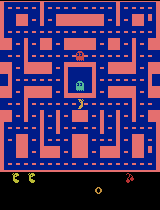

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'


  Episode 376/500 | 230,000 decisions | 57,251 updates | 15.3 min


Episode 376/500 | score 620 | recent mean 798.0 | exploration 20%


  Episode 377/500 | 230,500 decisions | 57,376 updates | 15.3 min


Episode 377/500 | score 740 | recent mean 800.0 | exploration 20%


...

  Episode 399/500 | 245,000 decisions | 61,001 updates | 16.2 min


Episode 399/500 | score 1550 | recent mean 848.0 | exploration 20%


  Episode 400/500 | 245,500 decisions | 61,126 updates | 16.2 min


Episode 400/500 | score 300 | recent mean 747.2 | exploration 20%


Separate demonstration score: 320.0
After 400 training games | 4× playback | 2 plays | first 20s of game time


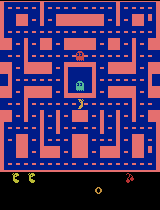

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'


  Episode 401/500 | 246,000 decisions | 61,251 updates | 16.3 min


  Episode 401/500 | 246,500 decisions | 61,376 updates | 16.3 min


Episode 401/500 | score 2140 | recent mean 808.0 | exploration 20%


  Episode 402/500 | 247,000 decisions | 61,501 updates | 16.3 min


...

  Episode 424/500 | 259,500 decisions | 64,626 updates | 17.0 min


Episode 424/500 | score 400 | recent mean 768.0 | exploration 20%


  Episode 425/500 | 260,000 decisions | 64,751 updates | 17.0 min


Episode 425/500 | score 480 | recent mean 775.2 | exploration 20%


Separate demonstration score: 440.0
After 425 training games | 4× playback | 2 plays | first 20s of game time


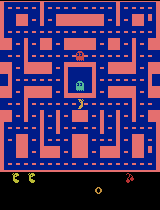

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'


  Episode 426/500 | 260,500 decisions | 64,876 updates | 17.1 min


Episode 426/500 | score 440 | recent mean 707.2 | exploration 20%


  Episode 427/500 | 261,000 decisions | 65,001 updates | 17.1 min


  Episode 427/500 | 261,500 decisions | 65,126 updates | 17.1 min


...

Episode 449/500 | score 1080 | recent mean 658.0 | exploration 20%


  Episode 450/500 | 275,000 decisions | 68,501 updates | 17.9 min


  Episode 450/500 | 275,500 decisions | 68,626 updates | 17.9 min


Episode 450/500 | score 1330 | recent mean 692.0 | exploration 20%


Separate demonstration score: 280.0
After 450 training games | 4× playback | 2 plays | first 20s of game time


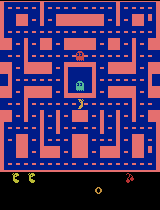

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'


  Episode 451/500 | 276,000 decisions | 68,751 updates | 18.0 min


  Episode 451/500 | 276,500 decisions | 68,876 updates | 18.0 min


Episode 451/500 | score 1370 | recent mean 729.2 | exploration 20%


Episode 452/500 | score 280 | recent mean 710.4 | exploration 20%


...

  Episode 474/500 | 290,000 decisions | 72,251 updates | 18.8 min


Episode 474/500 | score 300 | recent mean 673.2 | exploration 20%


  Episode 475/500 | 290,500 decisions | 72,376 updates | 18.8 min


Episode 475/500 | score 500 | recent mean 640.0 | exploration 20%


Separate demonstration score: 600.0
After 475 training games | 4× playback | 2 plays | first 20s of game time


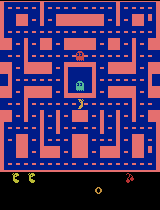

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'


  Episode 476/500 | 291,000 decisions | 72,501 updates | 18.8 min


Episode 476/500 | score 1250 | recent mean 635.2 | exploration 20%


  Episode 477/500 | 291,500 decisions | 72,626 updates | 18.9 min


Episode 477/500 | score 610 | recent mean 648.4 | exploration 20%


...

Episode 499/500 | score 530 | recent mean 918.0 | exploration 20%


  Episode 500/500 | 307,000 decisions | 76,501 updates | 19.7 min


  Episode 500/500 | 307,500 decisions | 76,626 updates | 19.8 min


Episode 500/500 | score 930 | recent mean 935.2 | exploration 20%


Separate demonstration score: 330.0
After 500 training games | 4× playback | 2 plays | first 20s of game time


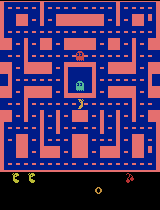

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'


Saved: pacman_runs/20260912_165849_959297


In [25]:
if _training_started:
    raise RuntimeError("Start a new experiment by rerunning from section 5a, or use Run All.")
_training_started = True
train_env = make_env()
started = time.monotonic()
status = "completed"
try:
    for episode in range(1, EPISODES + 1):
        row = train_one_episode(train_env, episode)
        history.append(row)
        completed_episodes = episode
        recent_mean = np.mean([game["score"] for game in history[-25:]])
        print(f"Episode {episode}/{EPISODES} | score {row['score']:.0f} | "
              f"recent mean {recent_mean:.1f} | exploration {row['exploration']:.0%}", flush=True)
        save_metrics(history, RUN_DIR / "training.csv")
        if episode % DEMO_EVERY == 0:
            save_progress_sample(episode)
except KeyboardInterrupt:
    status = "interrupted"
    print("Stopped early. Saving your agent; continue to section 6 for results.")
except Exception:
    status = "failed"
    raise
finally:
    train_env.close()
    save_training_result(status)
print("Saved:", RUN_DIR)
if updates == 0:
    print("No learning updates yet: this run ended before a training batch was ready.")

## 6. did it learn?

Compare all five games under the same settings. The highlighted GIF is the best of these five trained games;
it is an illustration, not the evidence by itself. Five games give a small comparison, not a reliable research estimate.

### 6a. play the saved agent

Reload the checkpoint and play the same five evaluation seeds. This tests both the saved file and the agent’s behavior.

In [26]:
# Load the saved model so the evaluation also verifies checkpoint playback.
checkpoint = torch.load(RUN_DIR / "trained.pt", map_location="cpu", weights_only=True)
trained_model = DQN(checkpoint["n_actions"]).to(DEVICE)
trained_model.load_state_dict(checkpoint["model"])
print("Evaluating the saved trained network on the same five games...", flush=True)
after = evaluate(trained_model, EVAL_SEEDS, RUN_DIR / "demos" / "final_best.gif", record_best=True)

Evaluating the saved trained network on the same five games...


### 6b. compare all five scores

Positive change means a higher average in this small test. A short run can get worse, and one good-looking sample is not enough to claim improvement.

  Game     Before      After
     1        350        330
     2        500         80
     3        320        460
     4        800        790
     5        490        740
  Mean      492.0      480.0
Change in mean score: -12.0
Time-limited games before / after: 0 / 0


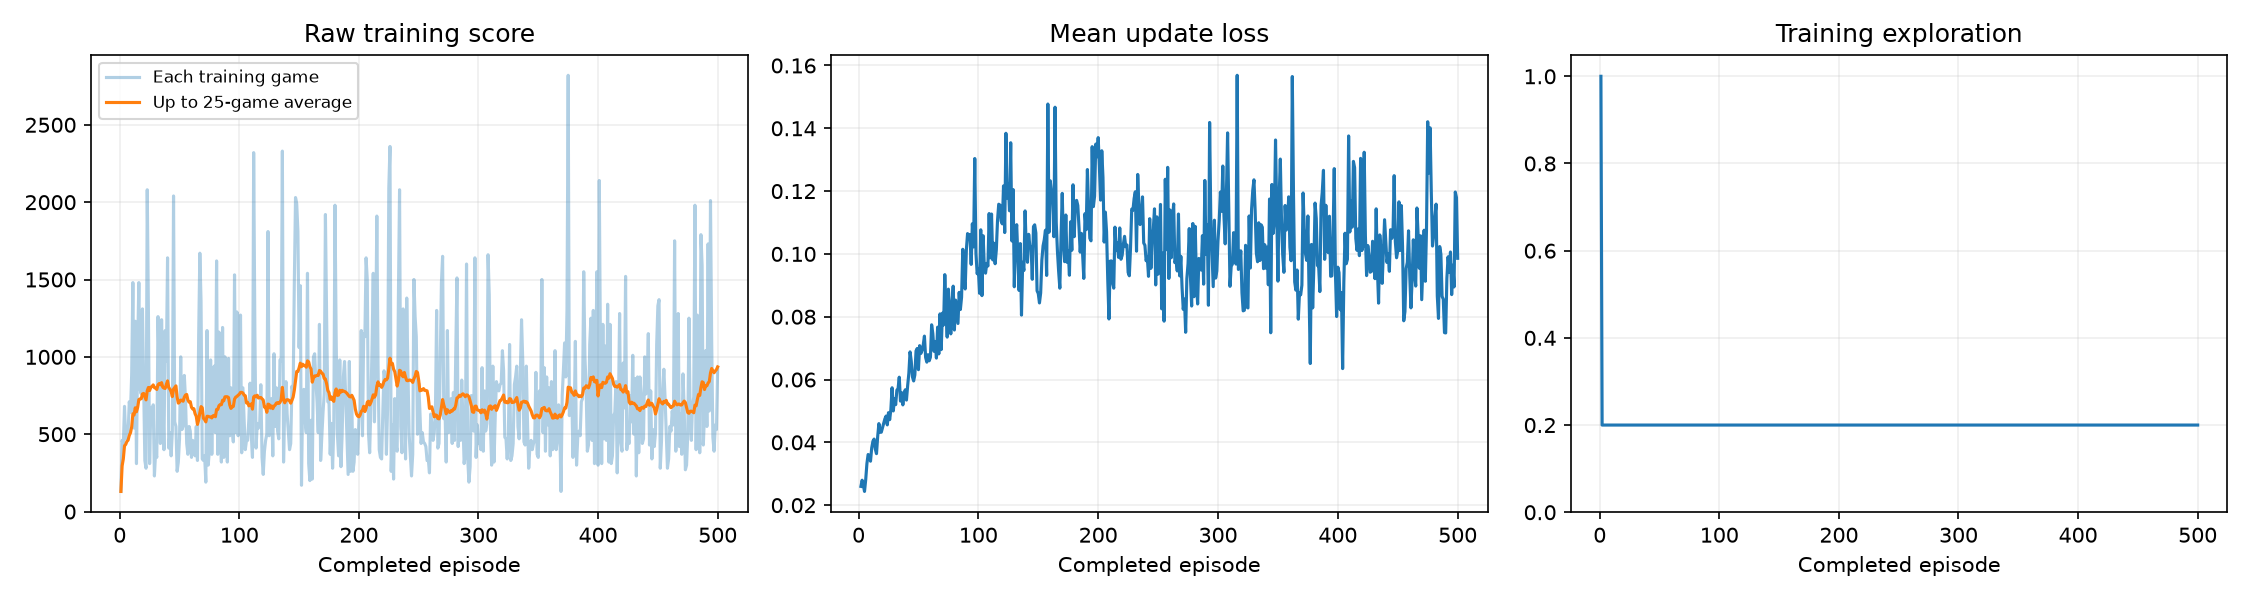

Final saved agent | 4× playback | 2 plays | first 20s of game time


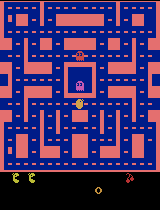

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'


In [27]:
comparison = {"baseline_kind": "untrained network", "before": baseline, "after": after,
              "evaluation_exploration": EVAL_EXPLORATION, "max_decisions_per_game": MAX_STEPS}
(RUN_DIR / "comparison.json").write_text(json.dumps(comparison, indent=2))
print(f"{'Game':>6} {'Before':>10} {'After':>10}")
for game, (before_score, after_score) in enumerate(zip(baseline["scores"], after["scores"]), 1):
    print(f"{game:>6} {before_score:>10.0f} {after_score:>10.0f}")
print(f"{'Mean':>6} {baseline['mean']:>10.1f} {after['mean']:>10.1f}")
print(f"Change in mean score: {after['mean'] - baseline['mean']:+.1f}")
print("Time-limited games before / after:", sum(baseline["time_limited"]), "/", sum(after["time_limited"]))
display(Image(filename=str(RUN_DIR / "training_dashboard.png")))
show_sample(RUN_DIR / "demos" / "final_best.gif", "Final saved agent")

## 7. save and explain your experiment

The next cell creates a ZIP containing your settings, package versions, all evaluation scores, training log,
plot, GIFs, and playback checkpoints. In Colab, download it before ending the session.
To try another setting, change the three choices and run all cells again; that starts from scratch.

Keep the notebook, plot, selected GIFs, comparison, and your explanation in your GitHub submission.
Model checkpoints can make repositories large; keep them locally or attach them to a GitHub release.

In [28]:
archive = shutil.make_archive(str(RUN_DIR), "zip", root_dir=RUN_DIR)
try:
    from google.colab import files
except ImportError:
    display(FileLink(archive, result_html_prefix="Download your experiment: "))
else:
    files.download(archive)
print("Results folder:", RUN_DIR.resolve())

/Users/kaylinyu/pacman_dqn/pacman_runs/20260912_165849_959297.zip

Results folder: /Users/kaylinyu/pacman_dqn/pacman_runs/20260912_165849_959297


### your explanation

- **My choices:** exploration = __, episodes = __, learning rate = __.
- **My prediction:** I expected these settings to __ because __.
- **What happened:** mean score before = __; after = __. In the gameplay, I noticed __.
- **One limitation:** __.
- **My next experiment:** change only __ to __ and keep the other two settings fixed.

The agent observes four screens, chooses a joystick action, and receives game rewards.
Lower training loss does not necessarily mean a higher game score. Report lack of progress if that is what happened.

### implementation notes and sources

This is a small, readable DQN experiment, not a reproduction of a large Atari benchmark.
Replay is deliberately small for laptops. Epsilon stays constant after warm-up. Checkpoints support playback;
rerunning starts a new experiment, rather than resuming the optimizer, replay memory, or an interrupted game.
GPU results can vary even with fixed seeds.

- [ALE installation and Gymnasium registration](https://ale.farama.org/getting-started/)
- [Gymnasium Atari preprocessing](https://gymnasium.farama.org/api/wrappers/misc_wrappers/#gymnasium.wrappers.AtariPreprocessing)
- [Gymnasium frame stacking](https://gymnasium.farama.org/api/wrappers/observation_wrappers/#gymnasium.wrappers.FrameStackObservation)
- [DQN paper: Human-level control through deep reinforcement learning](https://storage.googleapis.com/deepmind-media/dqn/DQNNaturePaper.pdf)